To upload a zip file from your local computer to this Colab environment, you can use the `files.upload()` function from `google.colab`. After running the code, a button will appear that allows you to select your file(s).

In [1]:
from google.colab import files

uploaded = files.upload()
for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving archive.zip to archive.zip
User uploaded file "archive.zip" with length 2316 bytes


In [2]:
import zipfile
import pandas as pd

# Unzip the uploaded archive.zip
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/extracted_data')

# Assuming the CSV file inside the zip is named 'Advertising.csv'
# Adjust the path if the CSV file has a different name or is in a subfolder
csv_file_path = '/content/extracted_data/Advertising.csv'
df = pd.read_csv(csv_file_path)

print(f"Successfully loaded '{csv_file_path}' into a pandas DataFrame.")

Successfully loaded '/content/extracted_data/Advertising.csv' into a pandas DataFrame.


In [3]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
display(df)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [ ]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
(200, 5)
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [4]:
# Drop the 'Unnamed: 0' column as it's an irrelevant index
df = df.drop(columns=['Unnamed: 0'])

print("DataFrame after dropping 'Unnamed: 0' column:")
display(df.head())
print(df.info())

DataFrame after dropping 'Unnamed: 0' column:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [6]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print(X.head())
print(y.head())

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [9]:
predictions = model.predict(X_test)

print(predictions[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # n_estimators is the number of trees
rf_model.fit(X_train, y_train)

print("Random Forest Model trained successfully")

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the Random Forest model
mae = mean_absolute_error(y_test, rf_predictions)
mse = mean_squared_error(y_test, rf_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_predictions)

print(f"\nRandom Forest Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display the first 10 predictions
print("\nFirst 10 Random Forest predictions:")
print(rf_predictions[:10])

Random Forest Model trained successfully

Random Forest Model Performance:
Mean Absolute Error (MAE): 0.62
Mean Squared Error (MSE): 0.59
Root Mean Squared Error (RMSE): 0.77
R-squared (R2): 0.98

First 10 Random Forest predictions:
[17.698 21.804 20.628  6.793 22.927 13.379 22.376  9.688 11.826 15.54 ]


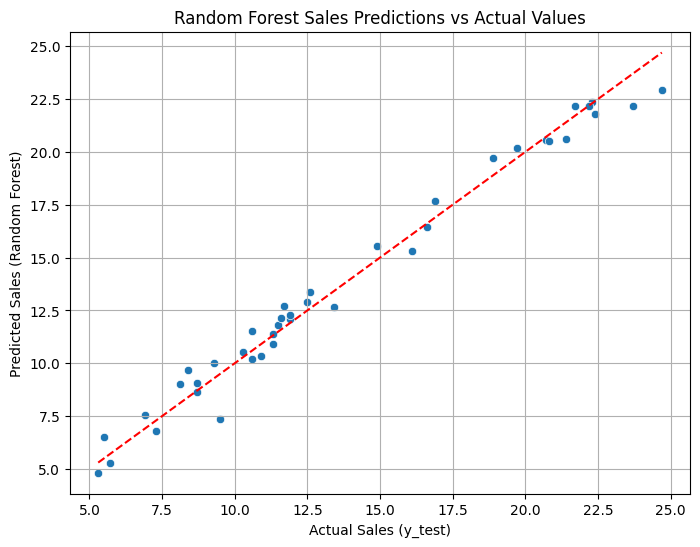

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Random Forest predictions vs actual sales
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=rf_predictions)
plt.xlabel("Actual Sales (y_test)")
plt.ylabel("Predicted Sales (Random Forest)")
plt.title("Random Forest Sales Predictions vs Actual Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Diagonal line for perfect prediction
plt.grid(True)
plt.show()

### Feature Importance from Random Forest Model

Let's analyze which features (advertising channels) were most important in the Random Forest model's predictions. This can give us insights into which channels have the strongest influence on sales.

Feature Importances:


,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


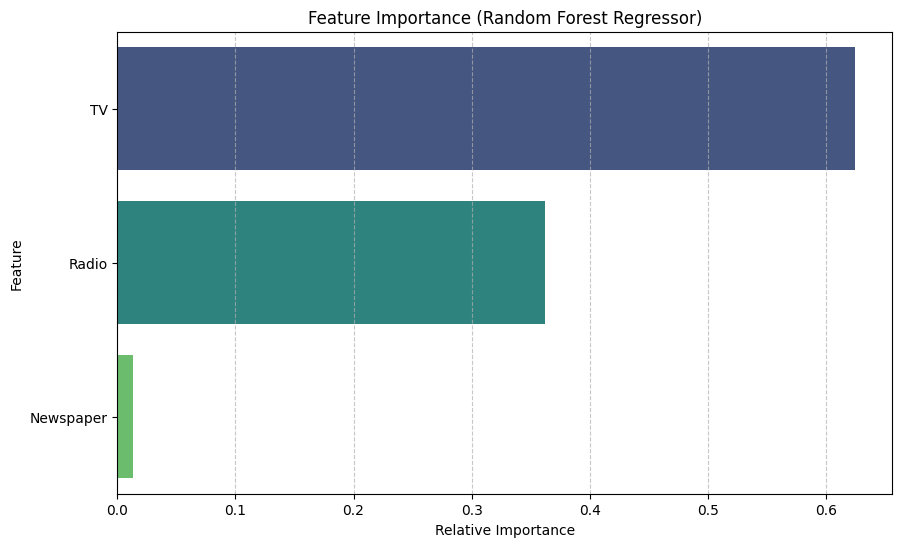

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(importance_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance (Random Forest Regressor)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Correlation Matrix:


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


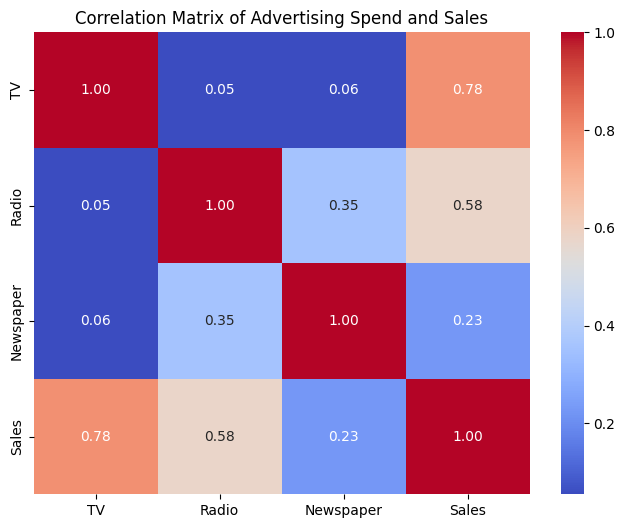

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Advertising Spend and Sales')
plt.show()

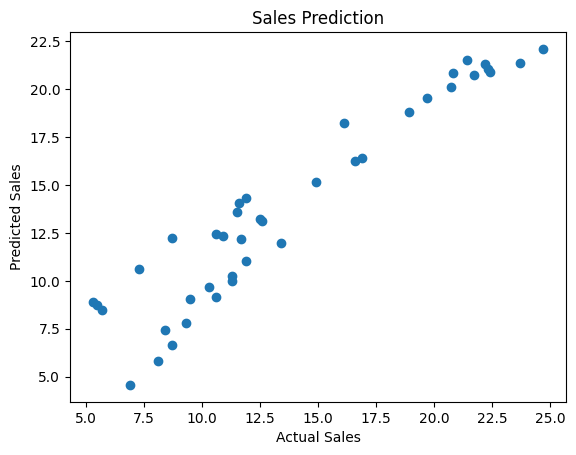

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Sales Prediction")
plt.show()

### Business Insights

Based on the Random Forest Feature Importance and the Correlation Matrix:

*   **TV Advertising is the Most Effective:** Both the feature importance (0.62) and the correlation (0.78) show that TV advertising has the strongest positive impact on sales. This suggests that investment in TV ads yields the highest returns.
*   **Radio Advertising is Also Significant:** Radio advertising also shows a substantial positive correlation (0.58) and feature importance (0.36). It's a valuable channel, though less impactful than TV.
*   **Newspaper Advertising has Minimal Impact:** Newspaper advertising has a very low feature importance (0.01) and a weak positive correlation (0.23) with sales. This indicates that it's the least effective advertising channel among the three, and resources allocated here might be better utilized elsewhere.

**Actionable Recommendations:**

1.  **Prioritize TV Advertising:** Businesses should continue to invest heavily in TV advertising campaigns.
2.  **Maintain or Optimize Radio Advertising:** While not as impactful as TV, Radio advertising still contributes significantly to sales. Further analysis could explore optimal spending levels for Radio.
3.  **Re-evaluate Newspaper Advertising:** Given its low impact, businesses should consider reducing or re-allocating their budget from Newspaper advertising to more effective channels like TV and Radio, or explore different strategies for Newspaper ads if they serve other marketing objectives.